In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
from jax.scipy.spatial.transform import Rotation as Rot



import genmetaballs.fmb.fm_render as fm_render
from genmetaballs.core import (
    FMB,
    Intrinsics,
    ThreeParameterBlender,
    ZeroParameterConfidence,
    geometry,
    make_fmb_scene_from_values,
    render_fmbs,
)
from genmetaballs.fmb.utils import DegradeLR, get_camera_rays, image_grid

Pose, Vec3D, Rotation = geometry.Pose, geometry.Vec3D, geometry.Rotation


# JAX setup (before importing)
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
np.random.seed(0)
print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend().upper()}")
print(f"JAX devices: {jax.devices()}")

Running cmake --build & --install in /home/matin/GenMetaBalls/build
JAX version: 0.8.0
JAX backend: GPU
JAX devices: [CudaDevice(id=0)]


In [2]:
def visualize_results(gmb, ref, title=''):
    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(8, 5))
    fig.suptitle(title)
    im0 = ax0.imshow(gmb)
    ax0.set_title("GenMetaBalls", fontsize=12, fontweight="bold")
    ax0.axis("off")
    plt.colorbar(im0, ax=ax0)
    
    ax1.set_title("Reference Impl.", fontsize=12, fontweight="bold")
    im1 = ax1.imshow(ref)
    ax1.axis("off")
    plt.colorbar(im1, ax=ax1)
    
    diff = gmb - ref
    ax2.set_title("Difference", fontsize=12, fontweight="bold")
    im2 = ax2.imshow(diff)
    ax2.axis("off")
    plt.colorbar(im2, ax=ax2)
    return jnp.linalg.norm(diff)


In [3]:
height, width = image_size = (64, 80)
focal_length = 2.0
cx = (width - 1) / 2
cy = (height - 1) / 2

In [4]:
# integer xy-coordinates (as opposed to ij coordinates) of the pixels in the image
# augmented with zeros
pixel_list = (
    (np.array(np.meshgrid(np.arange(width), height - np.arange(height) - 1, [0]))[:, :, :, 0])
    .reshape((3, -1))
    .T
)
# camera frame in get_camera rays has -z pointing into the image!!!!
camera_rays = get_camera_rays(focal_length, focal_length, cx, cy, pixel_list)
rays_trans = np.stack(
    [camera_rays, np.tile(np.zeros(3), (camera_rays.shape[0], 1))], 1
)

In [5]:
hyperparams = fm_render.hyperparams
beta2 = jnp.float32(np.exp(hyperparams[0]))
beta3 = jnp.float32(np.exp(hyperparams[1]))

## Single-FMB Agreement

In [6]:
mean = jnp.array([0., 0, -1])
extent = jnp.array([55.0, 4, 1])
# XXX what is rot exactly?
rot = Rot.from_euler('ZYX', jnp.array([jnp.pi/4, 0, 0]))

In [7]:
# reference impl
render_jit = jax.jit(fm_render.render_func_rays)

log_weights = np.zeros(1)
rotmat = rot.as_matrix()
# XXX what the reference impl. calls the "precision matrix" is
# actually the square root of the precision matrix
prec = rotmat @ np.diag(1/extent) @ rotmat.T
prec_chol = jnp.linalg.cholesky(prec)
ref_depth, ref_alpha, *_ = render_jit(
    mean[jnp.newaxis, ...], prec_chol[jnp.newaxis, ...], jnp.zeros(1), rays_trans, beta2, beta3
)

In [8]:
# GenMetaballs
camera = Intrinsics(fx=focal_length, fy=focal_length, cx=cx, cy=cy, width=width, height=height)
campose = geometry.Pose()

fmb = FMB(Pose.from_components(Rotation.from_quat(*rot.as_quat()), Vec3D(*mean)), *extent)
scene = make_fmb_scene_from_values([fmb], list(log_weights), device="gpu")

confidence = ZeroParameterConfidence()
blender = ThreeParameterBlender(beta1=beta3, beta2=beta2, eta=1.0)
image = render_fmbs(scene, blender, confidence, camera, campose)

img_view = image.as_view()
gmb_depth = img_view.depth.as_jax()
gmb_alpha = img_view.confidence.as_jax()

Array(0.00299456, dtype=float32)

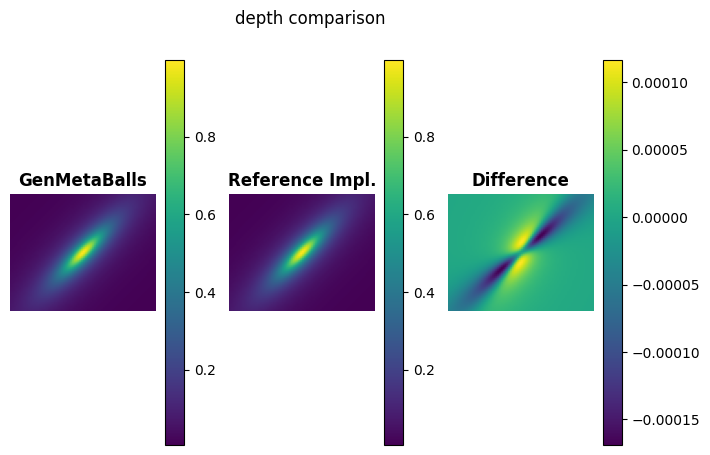

In [9]:
visualize_results(gmb_depth, ref_depth.reshape(image_size), title='depth comparison')

Array(0.0030724, dtype=float32)

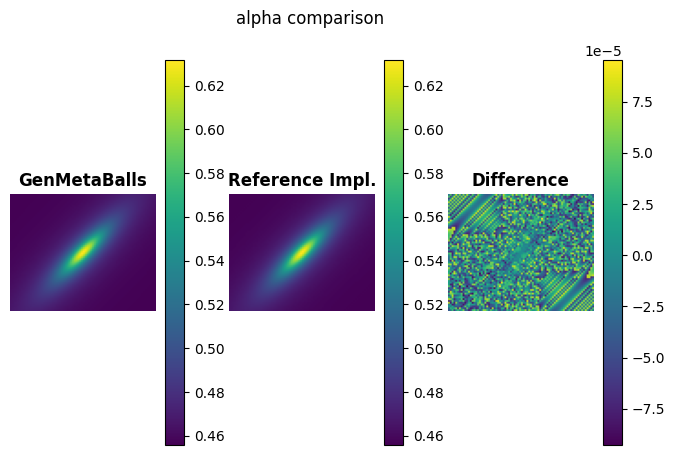

In [10]:
visualize_results(gmb_alpha, ref_alpha.reshape(image_size), title='alpha comparison')

## Multi-FMB Agreement

In [11]:
means = jnp.array([[-1., 0, -1], [1, 0, -2]])
extents = jnp.array([[55.0, 4, 1], [55.0, 4, 1]])
rots = [
    Rot.from_euler('ZYX', jnp.array([jnp.pi/4, 0, 0])),
    Rot.from_euler('ZYX', jnp.array([-jnp.pi/4, 0, 0]))
]
#means, extents, rots = means[1:2], extents[1:2], rots[1:2]
assert len(means) == len(extents) == len(rots)
N = len(means)
log_weights = np.zeros(N) - jnp.log(N)

In [12]:
# reference impl
rotmats = jnp.array([rot.as_matrix() for rot in rots])
# XXX what the reference impl. calls the "precision matrix" is
# actually the square root of the precision matrix
precs = jnp.array([rotmat @ np.diag(1/extent) @ rotmat.T for (rotmat, extent) in zip(rotmats, extents)])
prec_chols = jnp.linalg.cholesky(precs)
ref_depth, ref_alpha, *_ = render_jit(
    means, prec_chols, log_weights, rays_trans, beta2, beta3
)

In [13]:
# GenMetaballs
camera = Intrinsics(fx=focal_length, fy=focal_length, cx=cx, cy=cy, width=width, height=height)
campose = geometry.Pose()

fmbs = [FMB(Pose.from_components(Rotation.from_quat(*rot.as_quat()), Vec3D(*mean)), *extent)\
        for (mean, extent, rot) in zip(means, extents, rots)]
scene = make_fmb_scene_from_values(fmbs, list(log_weights), device="gpu")

confidence = ZeroParameterConfidence()
blender = ThreeParameterBlender(beta1=beta3, beta2=beta2, eta=1.0)
image = render_fmbs(scene, blender, confidence, camera, campose)

img_view = image.as_view()
gmb_depth = img_view.depth.as_jax()
gmb_alpha = img_view.confidence.as_jax()

Array(0.0514944, dtype=float32)

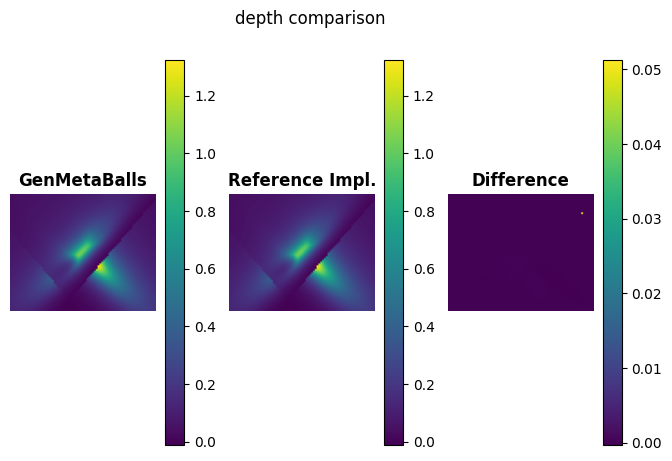

In [14]:
visualize_results(gmb_depth, ref_depth.reshape(image_size), title='depth comparison')

Array(0.00368901, dtype=float32)

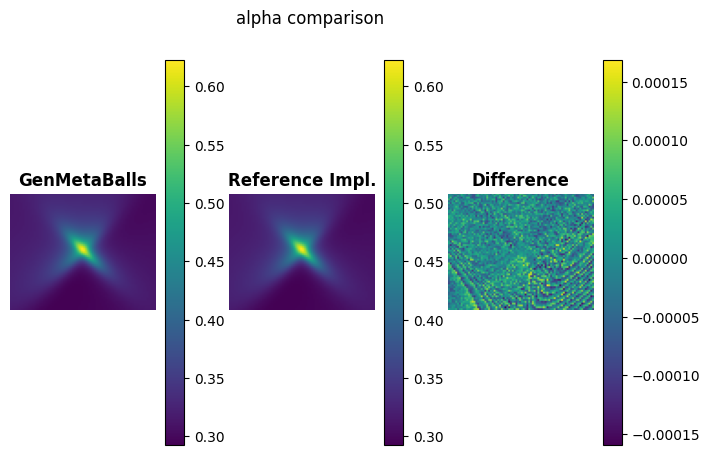

In [15]:
visualize_results(gmb_alpha, ref_alpha.reshape(image_size), title='alpha comparison')